# Fra molekyler til termodynamikk

:::{admonition} I dette kapitlet skal du lære å
:class: note

- forklare forskjellen mellom en mikroskopisk og en makroskopisk beskrivelse av et system
- forklare hva tilstandsvariabler, prosesser og tilstandsfunksjoner er
- beskrive forskjellen mellom indre energi og energi som overføres som varme eller arbeid
- bruke mikrotilstander og en enkel sannsynlighetsfordeling til å forklare hvorfor makroskopiske størrelser er stabile
- gjøre rede for den grunnleggende sammenhengen mellom energi, entropi og temperatur
:::

Hvorfor har en gass trykk? Hvorfor går varme fra en varm kaffekopp til rommet, og ikke motsatt? Hvorfor blander noen stoffer seg spontant, mens andre skiller lag? Og hvordan kan vi vite om en kjemisk reaksjon kan gå, før vi har prøvd den på laboratoriet?

Dette er ulike spørsmål, men de har en felles kjerne: Egenskapene vi observerer i laboratoriet oppstår fra bevegelsene, energiene og vekselvirkningene til et enormt antall atomer og molekyler. Fysikalsk kjemi handler i stor grad om å bygge bro mellom disse beskrivelsesnivåene.

![Fra partikkel til måling](Simuleringer/mikro_til_makro_horisontal.png)

I dette kapitlet skal vi se på hvordan tilfeldig bevegelse på molekylnivå kan gi stabile og forutsigbare egenskaper på makronivå, altså det vi kan observere direkte.

In [2]:
# Felles oppsett for figurene i dette kapitlet
import numpy as np
import matplotlib.pyplot as plt
from math import comb, lgamma, log, exp
from matplotlib.patches import Rectangle, FancyArrowPatch
from itertools import combinations

BLA, ORANSJE, GRONN = "#2b6cb0", "#c05621", "#2f855a"
GRA, LYSBLA, LYSORANSJE = "#718096", "#bee3f8", "#fbd38d"

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def binomial_pmf(N, n):
    """P(n) for N uavhengige forsøk med sannsynlighet 1/2. Bruker
    logaritmer slik at uttrykket ikke flyter over for store N."""
    return exp(lgamma(N + 1) - lgamma(n + 1) - lgamma(N - n + 1) - N * log(2))

## Hva kan fysikalsk kjemi hjelpe oss å forstå?

Som kjemikere møter vi noen spørsmål igjen og igjen:

1. **Hvilken retning har en prosess?** Vil en reaksjon gå mot produkter, vil en væske fordampe, eller vil to stoffer blande seg?
2. **Hvordan utveksles energi?** Hvor mye varme avgis, hvor mye arbeid kan utføres, og hvordan fordeles energien i systemet?
3. **Hvor ender prosessen?** Hvilke faser og hvilken sammensetning finner vi ved likevekt?
4. **Hvor raskt går den?** Hvilken mekanisme følger reaksjonen, og hva bestemmer reaksjonsfarten?

De tre første spørsmålene tilhører først og fremst **termodynamikken**. Det siste tilhører **kinetikken**. Skillet er viktig: En prosess kan være termodynamisk gunstig uten at den skjer merkbart raskt.

:::{admonition} Termodynamikk og kinetikk
:class: important

**Termodynamikk** beskriver energi, retning og likevekt. Den kan fortelle om en prosess *kan* skje og hvor systemet ender, men ikke hvor lang tid det tar.

**Kinetikk** beskriver hastighet og mekanisme. Den forteller hvor raskt en prosess skjer og hvilken vei den følger på molekylnivå.
:::

:::{admonition} Underveisoppgave
:class: tip

Bensin kan reagere med oksygen og danne karbondioksid og vann. Likevel kan bensin oppbevares i en lukket tank ved romtemperatur. Hvordan kan reaksjonen være termodynamisk gunstig uten at bensinen reagerer med en gang?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Produktene kan ha lavere Gibbs-energi enn reaktantene, slik at reaksjonen har en termodynamisk drivkraft. Reaksjonen har samtidig en energibarriere som gjør den svært langsom ved romtemperatur. En gnist gir noen molekyler nok energi til å passere barrieren. Termodynamikken beskriver retningen; kinetikken beskriver hvor raskt reaksjonen kommer i gang.
:::

## To beskrivelser av det samme systemet

Tenk deg ett mol argongass i en beholder. På laboratoriet kan vi beskrive gassen med noen få målbare størrelser, som vi kaller **tilstandsvariabler**, for eksempel trykk $P$, volum $V$ og temperatur $T$. Dette er en **makroskopisk beskrivelse**.

:::{admonition} Tilstandsvariabler
:class: important

Tilstandsvariabler er størrelser som beskriver tilstanden til et system.

En **ekstensiv** tilstandsvariabel avhenger av størrelsen til systemet. Eksempler er volum, masse, stoffmengde og indre energi.

En **intensiv** tilstandsvariabel er uavhengig av størrelsen til systemet. Eksempler er temperatur, trykk og tetthet.
:::

På atomnivå består den samme gassen av $N=N_\mathrm{A}\approx 6{,}022\times 10^{23}$ atomer. Hvis vi skulle beskrive alle disse partiklene med klassisk mekanikk, måtte vi oppgi tre posisjonskoordinater og tre hastighetskomponenter - én av hver for hver retning i rommet - for hvert eneste atom. Det gir $6N_\mathrm{A}\approx 3{,}6\times10^{24}$ tall for å beskrive ett eneste øyeblikk. I tillegg endrer alle tallene seg kontinuerlig fordi atomene beveger seg, kolliderer og påvirker hverandre med krefter. En slik beskrivelse lar seg rett og slett ikke gjennomføre.

Heldigvis trenger vi ikke å vite hva hvert enkelt atom gjør for å forstå hvordan de makroskopiske størrelsene oppstår. Det vi trenger å vite, er hvilke mikrotilstander som er tilgjengelige, hvor sannsynlige de er, og hvilke makroskopiske størrelser vi får når vi tar gjennomsnittet av dem. Dette er kjernen i **statistisk termodynamikk**. La oss derfor se nærmere på hva som menes med **makrotilstander** og **mikrotilstander**.

## Mikrotilstander og makrotilstander

En **makrotilstand** beskriver systemet med størrelser vi kan måle i laboratoriet, som temperatur, trykk, volum og indre energi. En **mikrotilstand** er én fullstendig mikroskopisk beskrivelse av systemet innenfor modellen vi bruker. En makrotilstand kan derfor ha mange mulige tilhørende mikrotilstander, men i et gitt øyeblikk vil bare én bestemt mikrotilstand være realisert. Tenk på den som et øyeblikksbilde av alle molekylene i en gass.

**Mikroskopisk:**

- Mikroskopisk nivå: når vi beskriver individuelle atomer eller molekyler.
- Mikroskopisk egenskap: energier, posisjoner og hastigheter til individuelle atomer eller molekyler.
- Mikrotilstand: den nøyaktige tilstanden til hvert enkelt atom eller molekyl i systemet. Det kan for eksempel være posisjoner og hastigheter eller hvilke energitilstander partiklene befinner seg i.

**Makroskopisk:**

- Makroskopisk nivå: når vi beskriver et system som helhet, slik vi kan observere og måle det. Et eksempel er egenskapene til en gass i en beholder.
- Makroskopisk egenskap: størrelser vi kan måle i laboratoriet, for eksempel temperatur, trykk, volum og indre energi.
- Makrotilstand: systemets tilstand beskrevet av et sett makroskopiske størrelser. Mange ulike mikrotilstander kan gi den samme makrotilstanden.

La oss se på et enkelt eksempel utenfor molekylverdenen, der vi kaster fire mynter. Makrotilstanden «to kron» kan realiseres med $\binom{4}{2}=6$ forskjellige mikrotilstander - avhengig av *hvilke* to mynter som viser kron. Makrotilstanden «fire kron» har bare én mikrotilstand. Dette har vi illustrert nedenfor. Der er antallet mikrotilstander vist for makrotilstandene «ingen kron», «én kron» og «to kron».

![Mikro- og makrotilstander](bilder/mikro_makro_mynter.svg)

:::{admonition} Underveisoppgave
:class: tip

Skriv makrotilstandene som mangler i figuren ovenfor, og tegn alle mulige mikrotilstander for disse makrotilstandene. Hint: Vi trenger egentlig ikke å regne ut noe for å vite hvor mange det blir. Hvorfor?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Makrotilstandene som mangler, er «tre kron» og «fire kron». Tre kron kan realiseres på fire måter, analogt til én kron ovenfor. Fire kron kan bare realiseres på én måte. Figuren er symmetrisk fordi det finnes like mange måter å velge hvilke mynter som viser kron, som hvilke mynter som viser mynt.
:::

La oss se på enda et eksempel. Tenk deg at du kaster to terninger. Det du bryr deg om, er summen av øynene - dette er makrotilstanden. Men det finnes mange forskjellige kombinasjoner av terning 1 og terning 2 som gir akkurat samme sum. Hver slik kombinasjon er en egen mikrotilstand, men de gir *samme* makrotilstand.

![Mikro og makro introduksjon](Simuleringer/terningkast_mikro_vs_makro.png)

Én eller flere mikrotilstander kan altså tilsvare en makrotilstand, men du kan ikke gå andre veien og forutsi den presise mikrotilstanden fra makrotilstanden. Hvis du bare vet at summen er 7, vet du ikke om det var $(3,4)$, $(1,6)$ eller $(5,2)$ som ble kastet.

**Vit hva systemet ditt er:**

Vi kan velge å se på et system som består av én terning. Hvis den observerbare størrelsen er antallet øyne, har systemet seks mikrotilstander og seks tilsvarende makrotilstander.

Vi kan også velge å se på et system som består av to terninger, som i figuren. Da blir det betydelig flere mulige mikrotilstander, og flere av dem kan gi opphav til samme makrotilstand.

Bryr vi oss om hvilken av de to terningene som viser hvilket tall? Eller bryr vi oss bare om summen? Det avhenger av spørsmålet vi ønsker å svare på, men vi er nødt til å velge _før_ vi teller tilstander. Det er derfor viktig å være tydelig på hva systemet er, hva vi observerer, og hvilken modell vi bruker.

## System og omgivelser

Før vi kan beskrive en prosess, må vi bestemme hva vi studerer. Vi trekker en fysisk eller tenkt grense rundt en del av universet og kaller denne delen **systemet**. Alt utenfor grensen er **omgivelsene**.

:::{admonition} Systemtyper
:class: important

- Et **åpent system** kan utveksle både materie og energi med omgivelsene.
- Et **lukket system** kan utveksle energi, men ikke materie, med omgivelsene.
- Et **isolert system** utveksler verken materie eller energi med omgivelsene.
:::

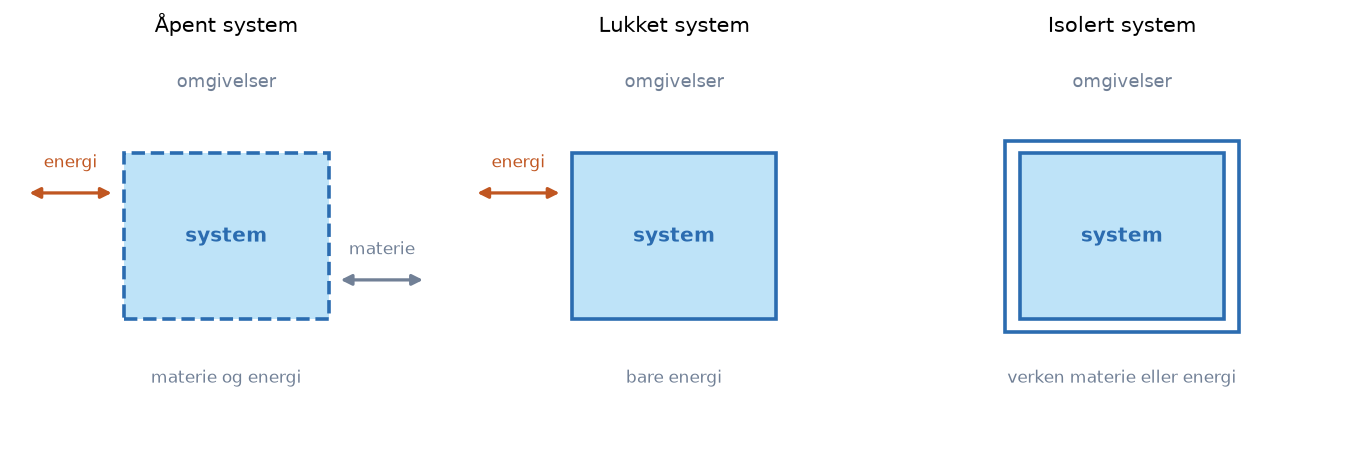

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))

typer = [("Åpent system",   True,  True,  "materie og energi"),
         ("Lukket system",  False, True,  "bare energi"),
         ("Isolert system", False, False, "verken materie eller energi")]

for ax, (navn, materie, energi, undertekst) in zip(axes, typer):
    ax.add_patch(Rectangle((0.26, 0.30), 0.48, 0.42, facecolor=LYSBLA, edgecolor=BLA,
                           lw=2, ls="--" if "Åpent" in navn else "-", zorder=2))
    if "Isolert" in navn:                      # dobbel vegg = ingen utveksling
        ax.add_patch(Rectangle((0.225, 0.268), 0.55, 0.484, facecolor="none",
                               edgecolor=BLA, lw=2, zorder=2))
    ax.text(0.5, 0.51, "system", ha="center", va="center", color=BLA,
            fontweight="bold", zorder=3)
    ax.text(0.5, 0.90, "omgivelser", ha="center", va="center", color=GRA, fontsize=10)

    if energi:
        ax.add_patch(FancyArrowPatch((0.03, 0.62), (0.24, 0.62), arrowstyle="<|-|>",
                                     mutation_scale=12, color=ORANSJE, lw=1.8))
        ax.text(0.135, 0.685, "energi", color=ORANSJE, ha="center", fontsize=9.5)
    if materie:
        ax.add_patch(FancyArrowPatch((0.76, 0.40), (0.97, 0.40), arrowstyle="<|-|>",
                                     mutation_scale=12, color=GRA, lw=1.8))
        ax.text(0.865, 0.465, "materie", color=GRA, ha="center", fontsize=9.5)

    ax.set_title(navn, fontsize=11.5)
    ax.text(0.5, 0.14, undertekst, ha="center", color=GRA, fontsize=9.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

fig.tight_layout()
plt.show()

In [4]:
Systemgrensen er et valg vi gjør. Dersom vi undersøker en reaksjon i en kolbe, kan systemet være reaksjonsblandingen, hele kolben eller kolben sammen med et vannbad. Valget avgjør hvilke energi- og stoffstrømmer vi må ta med i modellen.

:::{admonition} Underveisoppgave
:class: tip

En lukket kaffekopp med varm kaffe avkjøles på et bord. La kaffen være systemet.

1. Kan materie krysse systemgrensen?
2. Kan energi krysse systemgrensen?
3. Er systemet åpent, lukket eller isolert?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Hvis koppen er tett, krysser ikke materie grensen. Energi overføres derimot som varme fra kaffen til koppen og rommet. Systemet er derfor lukket, men ikke isolert.
:::

SyntaxError: invalid syntax (3022072221.py, line 1)

## Prosesser og tilstandsfunksjoner

Når én eller flere av tilstandsvariablene endrer seg, har systemet gjennomgått en **prosess**. En gass kan for eksempel gå fra en starttilstand med $(P_i,V_i,T_i)$ til en sluttilstand med $(P_f,V_f,T_f)$. Endringen i en størrelse $X$ skriver vi som

$$\Delta X=X_f-X_i.$$

En prosess beskriver altså en overgang mellom to tilstander. Men overgangen kan skje på forskjellige måter. En gass kan komprimeres raskt eller sakte, med god eller dårlig varmeutveksling med omgivelsene. Start- og sluttilstanden kan være de samme selv om veien mellom dem er forskjellig.

:::{admonition} Tilstandsfunksjon og stifunksjon
:class: important

En **tilstandsfunksjon** har en verdi som bare avhenger av systemets tilstand. Endringen avhenger derfor bare av start- og sluttilstanden, ikke av veien mellom dem. Indre energi $U$, entalpi $H$, entropi $S$ og Gibbs-energi $G$ er tilstandsfunksjoner.

En **stifunksjon** beskriver energi som overføres under selve prosessen, og avhenger av veien mellom start- og sluttilstanden. Varme $q$ og arbeid $w$ er stifunksjoner.
:::

Et intuitivt eksempel er en fjelltur. Høydeforskjellen mellom dalen og toppen er den samme uansett hvilken sti vi velger. Endringen i gravitasjonell potensiell energi er derfor bestemt av start- og sluttpunktet. Arbeidet vi utfører og varmen kroppen avgir, kan derimot avhenge av om stien er kort og bratt eller lang og slak.

Det samme gjelder for en gass. Figuren under viser to veier mellom de samme tilstandene A og B. Arealet under kurven svarer til arbeidet, og det er tydelig forskjellig for de to veiene. Fordi $\Delta U$ er den samme, må varmen $q$ kompensere for forskjellen.

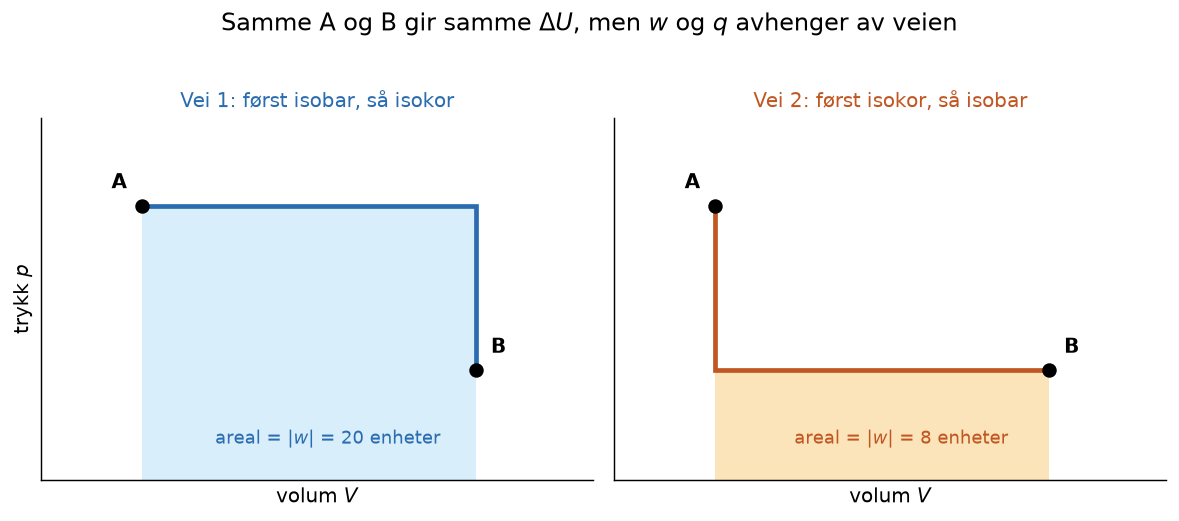

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.9), sharex=True, sharey=True)

# To veier mellom de samme tilstandene A = (2, 5) og B = (6, 2)
veier = [([2, 6, 6], [5, 5, 2], BLA,     LYSBLA,     "Vei 1: først isobar, så isokor", 20),
         ([2, 2, 6], [5, 2, 2], ORANSJE, LYSORANSJE, "Vei 2: først isokor, så isobar",  8)]

for ax, (V, p, farge, fyll, tittel, areal) in zip(axes, veier):
    ax.fill_between(V, p, 0, color=fyll, alpha=0.6, lw=0)
    ax.plot(V, p, color=farge, lw=2.6, solid_joinstyle="miter")
    for (v, pp), merke, dx in [((2, 5), "A", -0.18), ((6, 2), "B", 0.18)]:
        ax.plot(v, pp, "o", color="black", ms=7, zorder=5)
        ax.text(v + dx, pp + 0.32, merke, fontweight="bold",
                ha="right" if dx < 0 else "left")
    ax.set_title(tittel, fontsize=11, color=farge)
    ax.set_xlabel("volum $V$")
    ax.set_xlim(0.8, 7.4); ax.set_ylim(0, 6.6)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.text(0.52, 0.10, f"areal = $|w|$ = {areal} enheter", transform=ax.transAxes,
            ha="center", color=farge, fontsize=10)

axes[0].set_ylabel("trykk $p$")
fig.suptitle(r"Samme A og B gir samme $\Delta U$, men $w$ og $q$ avhenger av veien", y=1.02)
fig.tight_layout()
plt.show()

Vi bruker ulike begreper om forskjellige prosesser. Disse begrepene forteller oss hvilken betingelse som holdes konstant under prosessen:

| Prosess | Hva holdes konstant? | Betingelse |
|---|---|---|
| isoterm | temperatur | $\Delta T=0$ |
| isokor | volum | $\Delta V=0$ |
| isobar | trykk | $\Delta p=0$ |
| adiabatisk | ingen varmeutveksling | $q=0$ |

:::{admonition} Underveisoppgave
:class: tip

En gass går fra tilstand A til tilstand B langs to ulike veier. Langs den ene veien tilføres mye varme samtidig som gassen gjør mye arbeid. Langs den andre tilføres mindre varme og gassen gjør mindre arbeid.

Hvilken størrelse må ha samme endring langs de to veiene: $U$, $q$ eller $w$?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

$\Delta U$ må være den samme fordi indre energi er en tilstandsfunksjon og start- og sluttilstanden er like. $q$ og $w$ kan være forskjellige fordi de avhenger av veien. Energiregnskapet må likevel gå opp for begge veiene.
:::

## Energi: hva kan systemet lagre og utveksle?

Energi kan opptre i mange former og omdannes fra én form til en annen. I en forbrenningsmotor blir energi som lå i reaktantenes bindinger og vekselvirkninger omfordelt til molekylære frihetsgrader i produktene, særlig termisk bevegelse. Deler av denne energien forlater deretter systemet som mekanisk arbeid og varme. Den totale energien blir ikke borte, men ikke all energien kan omdannes til den formen vi ønsker.

På molekylnivå kan energi finnes som blant annet

- **translasjonsenergi** når molekylene beveger seg gjennom rommet
- **rotasjonsenergi** når molekylene roterer
- **vibrasjonsenergi** når bindinger strekkes og bøyes
- **elektronisk energi** knyttet til elektronenes tilstander
- **vekselvirkningsenergi** knyttet til de elektrostatiske kreftene mellom atomer, ioner og molekyler

For et molekylært system kan vi skjematisk skrive

$$U=E_\mathrm{trans}+E_\mathrm{rot}+E_\mathrm{vib}+E_\mathrm{elektronisk}+E_\mathrm{vekselvirkning}$$

Inndelingen er en modell, men den hjelper oss å se hvor systemet kan lagre energi. **Indre energi** $U$ er den samlede mikroskopiske energien i systemet. Bevegelsesenergien og den potensielle energien til hele systemet som ett makroskopisk legeme regnes vanligvis ikke med i $U$.

:::{admonition} Om «energi lagret i bindinger»
:class: error

Uttrykket kan være misvisende. Det krever energi å bryte en kjemisk binding, mens energi frigjøres når en binding dannes. En reaksjon avgir energi når dannelsen av nye bindinger og vekselvirkninger frigjør mer energi enn det som kreves for å bryte de gamle.
:::

Et system kan få endret indre energi på to grunnleggende måter: ved at energi overføres som **varme**, eller ved at det utføres **arbeid**. Med den vanlige kjemiske fortegnskonvensjonen er termodynamikkens første lov

$$\Delta U=q+w,$$

der $q>0$ når varme tilføres systemet, og $w>0$ når omgivelsene gjør arbeid på systemet.

Varme og arbeid er ikke noe systemet *inneholder*. De beskriver måter energi krysser systemgrensen på under en prosess. Når overføringen er ferdig, er energien en del av systemets indre energi.

:::{admonition} Energi og termodynamikkens første lov
:class: important

Energi kan ikke skapes eller ødelegges. Den kan overføres mellom system og omgivelser og omfordeles mellom ulike energiformer og mikroskopiske frihetsgrader. I et **lukket system** kan den indre energien bare endres ved at energi overføres som varme eller arbeid:

$$\Delta U=q+w.$$

I et åpent system kan $U$ i tillegg endres ved at materie krysser systemgrensen.
:::

:::{admonition} Underveisoppgave
:class: tip

Is ved smeltepunktet mottar varme og smelter uten at temperaturen øker. Har systemets indre energi likevel økt? Hvor har energien blitt av?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Ja. Energien brukes til å endre molekylenes vekselvirkninger og struktur når det ordnede isgitteret går over til flytende vann. Temperaturen trenger derfor ikke å øke selv om den indre energien gjør det.
:::

## Når tilfeldighet blir forutsigbar

At molekylene beveger seg tilfeldig, betyr ikke at systemets makroskopiske oppførsel er uforutsigbar. Tvert imot blir statistiske mønstre svært stabile når antallet partikler er stort.

Vi begynner med en enkel modell. Fire navngitte molekyler, A, B, C og D, kan befinne seg i venstre eller høyre halvdel av en beholder. Hvert molekyl har to muligheter, så systemet har totalt

$$2^4=16$$

mikrotilstander. Hvis vi bare observerer hvor mange molekyler som er på venstre side, får vi fem makrotilstander:

| Molekyler til venstre, $n$ | Multiplisitet $\Omega(n)$ | Sannsynlighet $p(n)$ |
|---:|---:|---:|
| 0 | 1 | $1/16$ |
| 1 | 4 | $4/16$ |
| 2 | 6 | $6/16$ |
| 3 | 4 | $4/16$ |
| 4 | 1 | $1/16$ |

Tabellen er vår første **sannsynlighetsfordeling**. Den viser alle verdiene størrelsen $n$ kan ha, og hvor sannsynlig hver verdi er.

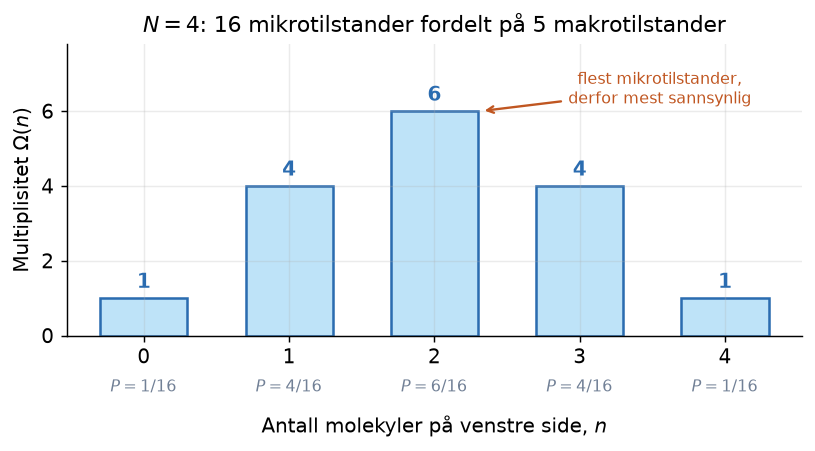

In [8]:
N = 4
n = np.arange(N + 1)
omega = np.array([comb(N, k) for k in n])

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.bar(n, omega, color=LYSBLA, edgecolor=BLA, lw=1.4, width=0.6)

for k, w in zip(n, omega):
    ax.text(k, w + 0.15, f"{w}", ha="center", va="bottom", color=BLA, fontweight="bold")
    ax.text(k, -0.15, f"$P={w}/16$", ha="center", va="top", color=GRA, fontsize=9,
            transform=ax.get_xaxis_transform())

ax.annotate("flest mikrotilstander,\nderfor mest sannsynlig", xy=(2.32, 6), xytext=(3.55, 7.1),
            color=ORANSJE, fontsize=9, ha="center", va="top",
            arrowprops=dict(arrowstyle="->", color=ORANSJE, lw=1.3))

ax.set_xlabel("Antall molekyler på venstre side, $n$", labelpad=26)
ax.set_ylabel(r"Multiplisitet $\Omega(n)$")
ax.set_title(r"$N=4$: 16 mikrotilstander fordelt på 5 makrotilstander")
ax.set_xticks(n); ax.set_ylim(0, 7.8)
fig.tight_layout()
plt.show()

Figuren viser det samme som tabellen, men gjør det lettere å se formen på fordelingen.

:::{admonition} Sannsynlighetsfordeling
:class: important

En **sannsynlighetsfordeling** er en oversikt, for eksempel en tabell eller en funksjon, som viser hvordan sannsynligheten er fordelt mellom alle mulige utfall.

Sannsynlighetene må til sammen være 1, fordi ett av de mulige utfallene må inntreffe.
:::

I denne modellen er venstre og høyre side like sannsynlige for hvert molekyl. Hver bestemte mikrotilstand har derfor sannsynligheten $(1/2)^N$. Antallet mikrotilstander med $n$ molekyler på venstre side er

$$\Omega(n)=\binom{N}{n},$$

og sannsynlighetsfordelingen blir

$$P(n)=\frac{\Omega(n)}{2^N}=\binom{N}{n}\left(\frac{1}{2}\right)^N.$$

Uttrykket teller hvor mange mikrotilstander som gir hver makrotilstand, og deler på det totale antallet mikrotilstander.

Makrotilstanden med to molekyler på hver side er ikke mer sannsynlig fordi molekylene _søker_ mot midten eller _prøver_ å fordele seg jevnt. Den er mer sannsynlig fordi den kan realiseres på flest måter.

:::{admonition} Multiplisitet
:class: important

**Multiplisiteten** $\Omega$ er antallet mikrotilstander som er forenlige med en bestemt makrotilstand.

Når alle tilgjengelige mikrotilstander er like sannsynlige, er sannsynligheten for en makrotilstand proporsjonal med multiplisiteten:

$$P(\text{makrotilstand})=\frac{\Omega}{\Omega_\mathrm{tot}}.$$
:::

:::{admonition} Underveisoppgave
:class: tip

Bruk tabellen til å sammenligne disse hendelsene:

1. alle fire molekylene er på venstre side
2. to molekyler er på hver side

Hvor mange ganger mer sannsynlig er den andre makrotilstanden enn den første? Betyr svaret at en skjev fordeling er umulig?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Sannsynlighetene er henholdsvis $1/16$ og $6/16$. En lik fordeling er derfor seks ganger mer sannsynlig enn at alle er på venstre side. Den skjeve fordelingen er likevel fullt mulig i et system med fire molekyler. Forskjellen mellom «usannsynlig» og «umulig» blir viktig når vi skalerer opp.
:::

En mer systematisk innføring i matematikken bak sannsynlighetsfordelinger finnes i appendiksene [Kombinatorikk](matematikk/kombinatorikk.ipynb) og [Sannsynlighetsfordelinger og statistikk](matematikk/statistikk.ipynb). Resten av dette kapitlet krever bare den intuitive forståelsen vi har utviklet her.

## Broa videre

Vi har nå språket vi trenger for å gå fra molekyler til termodynamikk:

:::{admonition} Fra mikro til makro
:class: important

Den mikroskopiske modellen bestemmer hvilke tilstander og energier som er mulige. Statistisk mekanikk beskriver hvor sannsynlige tilstandene er. Termodynamikken beskriver resultatet vi kan måle.
:::

Så langt har vi bare telt mikrotilstander som er like sannsynlige. Det gir et viktig spørsmål: Når en makrotilstand kan realiseres på mange flere måter enn en annen, hvordan kan vi uttrykke denne forskjellen som en målbar termodynamisk størrelse? I neste kapittel bruker vi multiplisiteten til å innføre entropi og temperatur. Derfra kommer vi fram til Boltzmann-fordelingen, som beskriver hvordan sannsynligheten fordeles mellom mikrotilstander med ulik energi.

[Fortsett til entropi, temperatur og Boltzmann-fordelingen](entropi_og_boltzmann.ipynb)

:::{admonition} Før du går videre
:class: tip

Prøv å forklare følgende med egne ord:

1. Hva er forskjellen mellom et åpent, et lukket og et isolert system?
2. Hva er en prosess, og hvorfor kan $\Delta U$ være den samme langs to veier selv om $q$ og $w$ er forskjellige?
3. Hva er forskjellen mellom en mikrotilstand og en makrotilstand?
4. Hva forteller en sannsynlighetsfordeling?
5. Hvorfor er en makrotilstand med stor multiplisitet mer sannsynlig når mikrotilstandene er like sannsynlige?
6. Hva er forskjellen mellom indre energi, varme og temperatur?
7. Hva kan termodynamikken ikke fortelle oss om en reaksjon?
:::
